# EDA — FinancialPhraseBank

Objectif : comprendre FPB avant d'écrire `prepare_fpb.py`.
Chaque section répond à une question qui mène à une décision de preprocessing.

## 0. Imports et chemins

In [1]:
from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Le notebook tourne depuis notebooks/ : on remonte à la racine du projet
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FPB_DIR = ROOT / "data" / "raw" / "fpb" / "FinancialPhraseBank-v1.0"

LABELS = ["negative", "neutral", "positive"]
# Couleurs par polarité : rouge = négatif, gris = neutre, bleu = positif
COLORS = {"negative": "#e34948", "neutral": "#8c8b86", "positive": "#2a78d6"}

pd.set_option("display.max_colwidth", 200)
sorted(p.name for p in FPB_DIR.iterdir())

['License.txt',
 'README.txt',
 'Sentences_50Agree.txt',
 'Sentences_66Agree.txt',
 'Sentences_75Agree.txt',
 'Sentences_AllAgree.txt']

## 1. Charger les 4 sous-ensembles

Format d'une ligne : `phrase@label`, encodage latin-1.
On coupe sur le **dernier** `@` (`rpartition`) : par précaution, si une phrase contenait un `@`, le label resterait correct.

In [2]:
FILES = {
    "50": "Sentences_50Agree.txt",
    "66": "Sentences_66Agree.txt",
    "75": "Sentences_75Agree.txt",
    "all": "Sentences_AllAgree.txt",
}

def load_fpb(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="latin-1").splitlines():
        if not line.strip():
            continue
        text, _, label = line.rpartition("@")
        rows.append({"text": text.strip(), "label": label.strip()})
    return pd.DataFrame(rows)

fpb = {name: load_fpb(FPB_DIR / f) for name, f in FILES.items()}
fpb["all"].head()

,text,label
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",neutral
1,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",positive
2,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .",positive
3,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,positive
4,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .",positive


## 2. Taille et répartition des classes

→ Décision : quel sous-ensemble, split stratifié, métrique macro-F1.

In [3]:
dist = pd.DataFrame({name: df["label"].value_counts() for name, df in fpb.items()}).T[LABELS]
dist["total"] = dist.sum(axis=1)
pct = dist[LABELS].div(dist["total"], axis=0).mul(100).round(1).add_suffix(" %")
pd.concat([dist, pct], axis=1)

label,negative,neutral,positive,total,negative %,neutral %,positive %
50,604,2879,1363,4846,12.5,59.4,28.1
66,514,2535,1168,4217,12.2,60.1,27.7
75,420,2146,887,3453,12.2,62.1,25.7
all,303,1391,570,2264,13.4,61.4,25.2


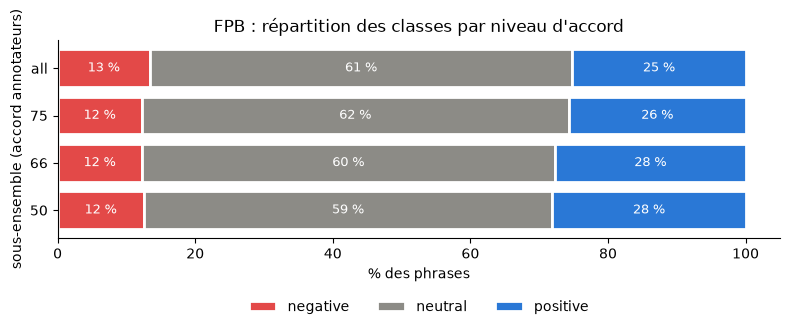

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
left = pd.Series(0.0, index=pct.index)
for label in LABELS:
    share = pct[f"{label} %"]
    ax.barh(pct.index, share, left=left, color=COLORS[label], label=label,
            edgecolor="white", linewidth=2)
    for y, (l, s) in enumerate(zip(left, share)):
        ax.text(l + s / 2, y, f"{s:.0f} %", ha="center", va="center", color="white", fontsize=9)
    left += share
ax.set_xlabel("% des phrases")
ax.set_ylabel("sous-ensemble (accord annotateurs)")
ax.set_title("FPB : répartition des classes par niveau d'accord")
ax.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Les sous-ensembles sont-ils imbriqués ?

Si AllAgree ⊂ 75Agree ⊂ 66Agree ⊂ 50Agree, on ne doit **jamais** entraîner sur l'un et tester sur un autre
(les mêmes phrases se retrouveraient des deux côtés).

In [5]:
sets = {name: set(df["text"]) for name, df in fpb.items()}
for small, big in [("all", "75"), ("75", "66"), ("66", "50")]:
    inside = len(sets[small] & sets[big]) / len(sets[small]) * 100
    print(f"{small:>3} ⊂ {big:>2} ? {inside:.1f} % des phrases de '{small}' sont dans '{big}'")

all ⊂ 75 ? 100.0 % des phrases de 'all' sont dans '75'
 75 ⊂ 66 ? 100.0 % des phrases de '75' sont dans '66'
 66 ⊂ 50 ? 100.0 % des phrases de '66' sont dans '50'


## 4. Doublons et conflits de labels

- **Doublon exact** : même phrase, même label → à garder une seule fois.
- **Conflit** : même phrase, labels différents → bruit, à supprimer.

→ Décision : dédoublonner **avant** le split, sinon une même phrase peut tomber en train ET en test (fuite).

In [6]:
rows = []
for name, df in fpb.items():
    n_dup_exact = df.duplicated(subset=["text", "label"]).sum()
    uniq = df.drop_duplicates(subset=["text", "label"])
    n_conflict = uniq["text"].duplicated(keep=False).sum()
    rows.append({"subset": name, "lignes": len(df), "doublons exacts": n_dup_exact,
                 "phrases en conflit": n_conflict})
pd.DataFrame(rows).set_index("subset")

,lignes,doublons exacts,phrases en conflit
subset,,,
50,4846,6,4
66,4217,6,0
75,3453,5,0
all,2264,5,0


In [7]:
# Exemples de doublons dans le sous-ensemble 75
df = fpb["75"]
df[df["text"].duplicated(keep=False)].sort_values("text").head(10)

,text,label
1544,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
1545,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
1681,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
1682,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
2195,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , c...",neutral
2196,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , c...",neutral
773,The issuer is solely responsible for the content of this announcement .,neutral
774,The issuer is solely responsible for the content of this announcement .,neutral
958,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. ...",neutral
959,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. ...",neutral


## 5. Phrases contenant un `@`

On vérifie le parsing : y a-t-il des `@` dans les phrases, et trouve-t-on exactement 3 labels ?

In [8]:
df = fpb["50"]
with_at = df[df["text"].str.contains("@", regex=False)]
print(f"{len(with_at)} phrases contiennent '@'")
print("labels trouvés :", sorted(df["label"].unique()))   # doit être exactement les 3 labels
with_at.head()

0 phrases contiennent '@'
labels trouvés : ['negative', 'neutral', 'positive']


,text,label


## 6. Longueur des phrases (en mots)

→ Décision (étape 3) : `max_length` des Transformers. Un token ≈ 1,3 mot en anglais,
on vérifiera avec le vrai tokenizer plus tard.

In [9]:
df = fpb["75"].assign(n_words=lambda d: d["text"].str.split().str.len())
df.groupby("label")["n_words"].describe(percentiles=[0.5, 0.95, 0.99]).round(1)

,count,mean,std,min,50%,95%,99%,max
label,,,,,,,,
negative,420.0,24.5,10.1,5.0,22.0,44.0,50.0,56.0
neutral,2146.0,21.5,9.8,2.0,20.0,40.0,49.0,81.0
positive,887.0,24.9,10.3,6.0,23.0,44.7,50.1,57.0


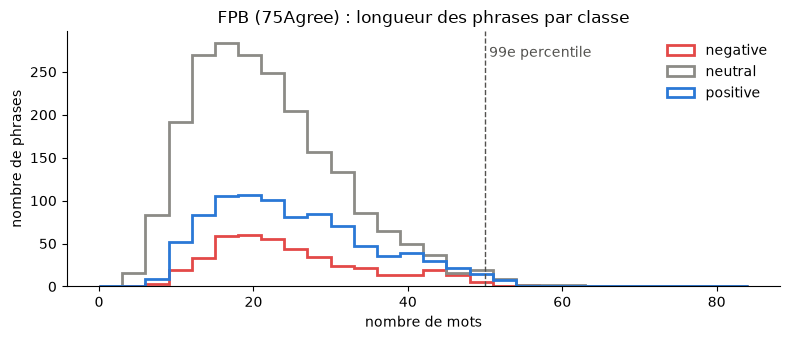

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = range(0, df["n_words"].max() + 5, 3)
for label in LABELS:
    ax.hist(df.loc[df["label"] == label, "n_words"], bins=bins, histtype="step",
            linewidth=2, color=COLORS[label], label=label)
p99 = df["n_words"].quantile(0.99)
ax.axvline(p99, color="#52514e", linestyle="--", linewidth=1)
ax.text(p99, ax.get_ylim()[1] * 0.9, " 99e percentile", color="#52514e")
ax.set_xlabel("nombre de mots")
ax.set_ylabel("nombre de phrases")
ax.set_title("FPB (75Agree) : longueur des phrases par classe")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Lire des exemples

Le plus important de l'EDA : **lire** les données pour sentir ce qui fait qu'une phrase est positive, négative ou neutre.

In [11]:
df = fpb["75"]
for label in LABELS:
    print(f"\n===== {label.upper()} =====")
    for t in df[df["label"] == label].sample(5, random_state=0)["text"]:
        print("-", t)


===== NEGATIVE =====
- Last year , UPM cut production , closed mills in Finland and slashed 700 jobs .
- Group EBIT for the first half was EUR13 .6 m US$ 17.8 m , falling short of the EUR22 .5 m it posted for the same period of 2009 .
- ADP News - Apr 22 , 2009 - Finnish business information systems developer Solteq Oyj HEL : STQ1V said today its net loss widened to EUR 189,000 USD 245,000 for the first quarter of 2009 from EUR 10,000 for the same peri
- Finnish laboratory liquid handling and diagnostic test systems developer Biohit Oyj OMX Helsinki : BIOBV issued on Tuesday 3 June a profit warning for the financial year 2008 .
- In Finland , snow storms brought trees down on power lines , cutting off electricity for some 2,000 households .

===== NEUTRAL =====
- The non-recurring costs caused to Talentum 's Premedia business area by the restructuring will amount to 2.0 mln euro $ 2.7 mln and will be included in the company 's financial results for the second quarter of 2007 .
- In ad

## 8. Mots les plus fréquents par classe

Intuition de ce que la baseline TF-IDF va apprendre.

In [12]:
def tokens(text: str) -> list[str]:
    return [w for w in re.findall(r"[a-z]+", text.lower())
            if w not in ENGLISH_STOP_WORDS and len(w) > 2]

df = fpb["75"]
top = {label: Counter(w for t in df.loc[df["label"] == label, "text"] for w in tokens(t)).most_common(15)
       for label in LABELS}
pd.DataFrame({label: [f"{w} ({c})" for w, c in top[label]] for label in LABELS})

,negative,neutral,positive
0,eur (374),company (382),eur (601)
1,profit (149),eur (287),year (194)
2,net (98),finland (161),net (186)
3,year (87),million (155),profit (185)
4,operating (86),group (145),sales (161)
5,sales (85),said (142),said (156)
6,quarter (83),business (141),finnish (152)
7,finnish (76),shares (140),million (143)
8,period (73),sales (131),company (140)
9,million (69),new (124),period (137)


## 9. Conclusions → décisions pour `prepare_fpb.py`

À remplir ensemble après avoir lu les résultats :

- Sous-ensemble choisi : …
- Dédoublonnage : …
- Split : …
- Métrique : …
- `max_length` envisagé : …